### **TODO 1: Import required libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud
from collections import Counter

# NLP
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer



### **TODO 2: Load, clean and preprocess the raw review data from the CSV file.**

In [20]:
df = pd.read_csv('/content/amazon_product_reviews.csv')

# Keep only needed columns
df = df[['reviews.text', 'reviews.rating']]

# Rename columns (IMPORTANT for tests)
df.columns = ['review', 'rating']

# Drop nulls
df.dropna(inplace=True)

# Lowercase
df['review'] = df['review'].str.lower()

# Remove special characters
df['review'] = df['review'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

### **TODO 3: Perform exploratory data analysis (EDA) and visualize key trends using Matplotlib/Seaborn.**

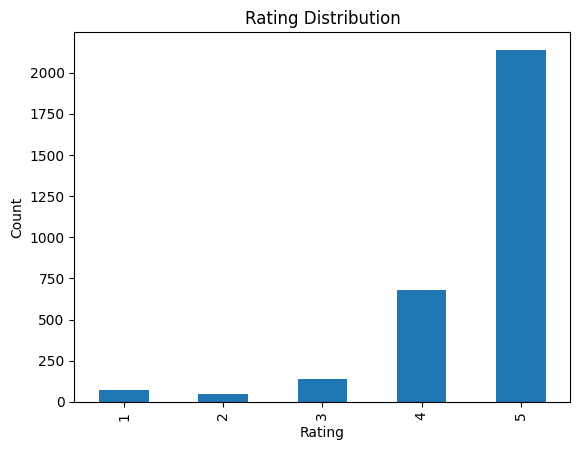

In [21]:
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

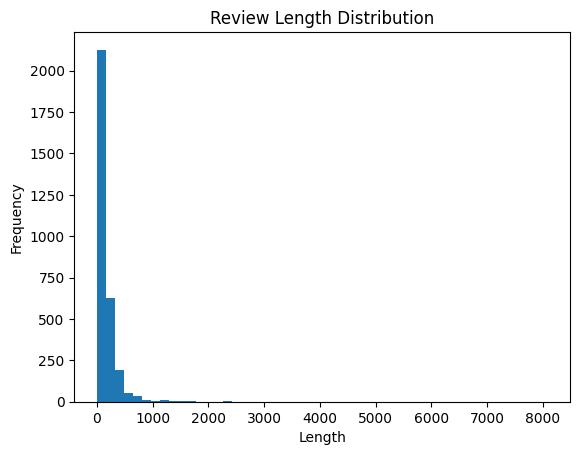

In [22]:
df['review_length'] = df['review'].apply(len)

plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### **TODO 4: Do sentiment/text analysis on feedback column using prompts and create a wordcloud for the most repeated feedback.**

In [28]:
from textblob import TextBlob

def get_sentiment_textblob(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['review'].apply(get_sentiment_textblob)

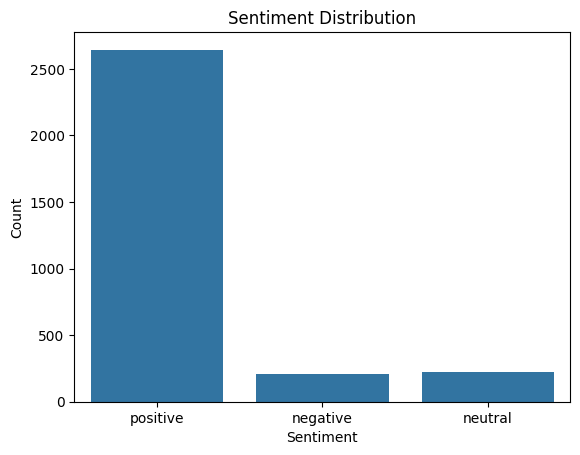

In [24]:
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

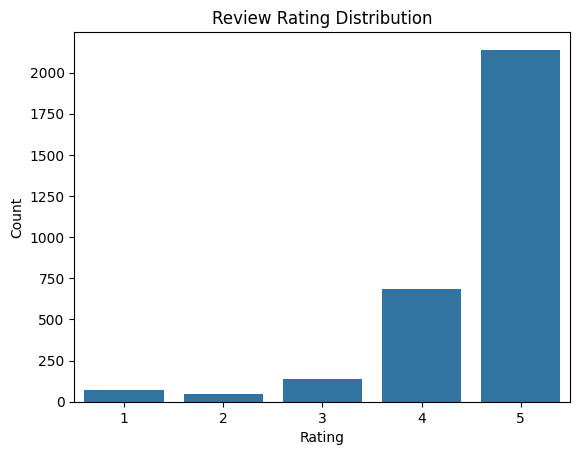

In [25]:
plt.figure()
sns.countplot(x='rating', data=df)
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

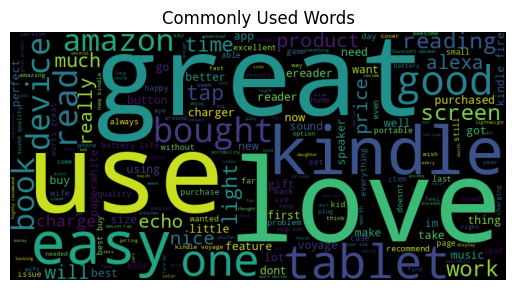

In [29]:
text = " ".join(df['review'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Commonly Used Words")
plt.show()

### **TODO 5: Create a barplot showing the most frequent words in negative reviews**

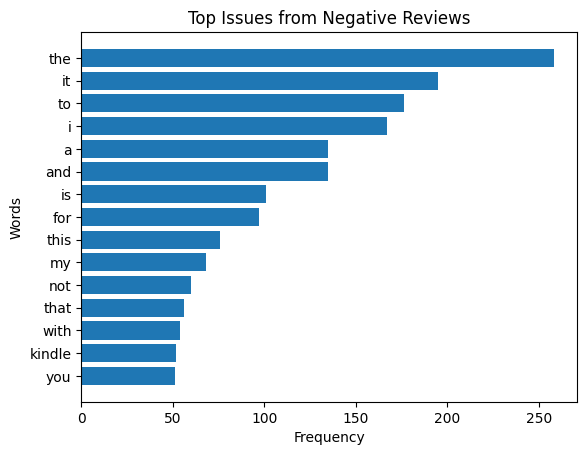

In [30]:
negative_df = df[df['sentiment'] == 'negative']

text = " ".join(negative_df['review'])

words = text.split()

# Count frequency (removed stop_words filtering)
word_freq = Counter(words)

top_words = dict(word_freq.most_common(15))

# Plot
plt.figure()
plt.barh(list(top_words.keys()), list(top_words.values()))
plt.title("Top Issues from Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.gca().invert_yaxis()
plt.show()